In [1]:
import pypsa

INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, stores, sub_networks


{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x24c1f894ad0>},
 'branches': {'Link': <matplotlib.collections.LineCollection at 0x24c1f8957f0>,
  'Line': <matplotlib.collections.LineCollection at 0x24c1f8d07d0>},
 'flows': {}}

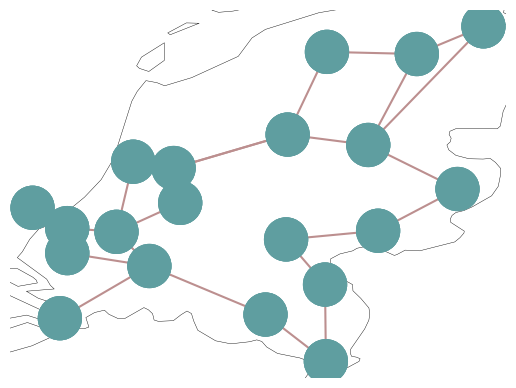

In [2]:
n = pypsa.Network("../external/pypsa-eur/resources/nl20/networks/base_s_20_elec.nc")
n.plot()

In [21]:
n.buses.to_csv("nl20_buses.csv")
n.lines.to_csv("nl20_lines.csv")
n.generators.to_csv("nl20_generators.csv")
n.loads.to_csv("nl20_loads.csv")

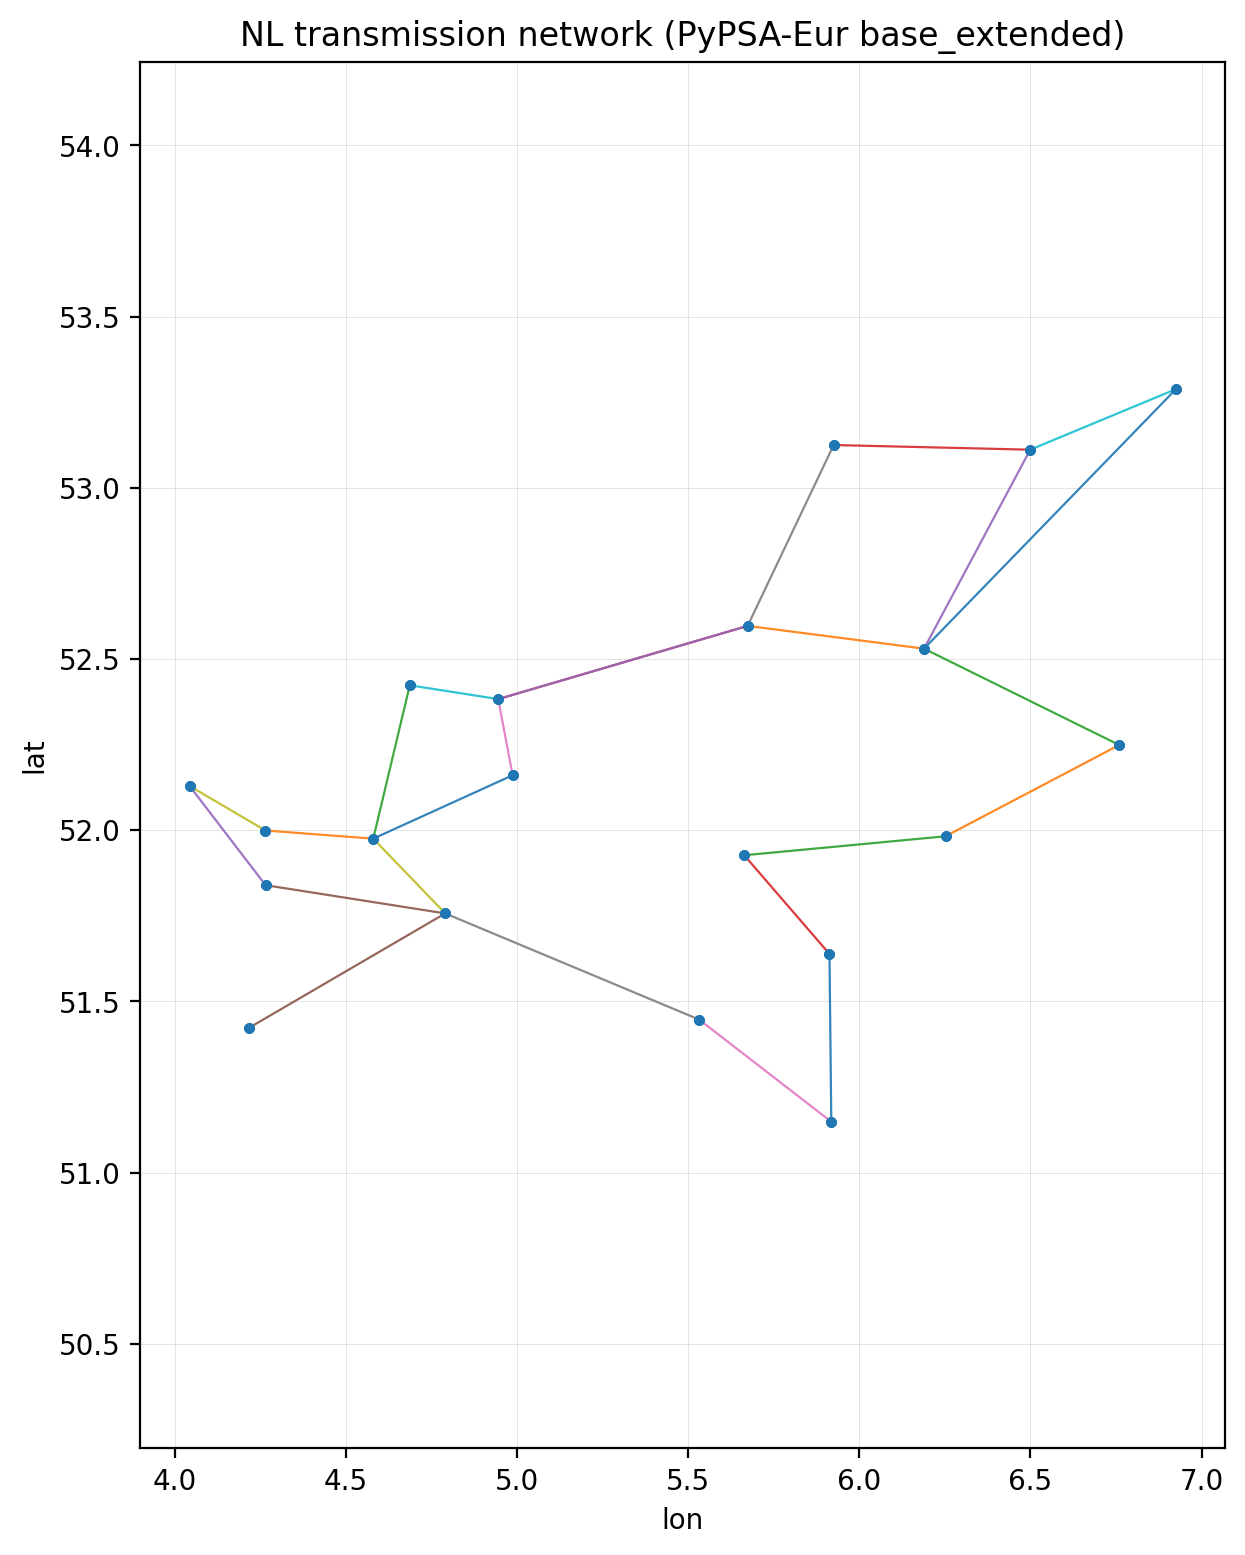

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

b = n.buses

# no cross-border lines
nl_buses = b.index[b.country == "NL"]
lines_nl = n.lines.index[n.lines.bus0.isin(nl_buses) & n.lines.bus1.isin(nl_buses)]

# plot
fig, ax = plt.subplots(figsize=(7, 9), dpi=200)

# draw lines
for l in lines_nl:
    bus0 = n.lines.at[l, "bus0"]
    bus1 = n.lines.at[l, "bus1"]
    x0, y0 = n.buses.at[bus0, "x"], n.buses.at[bus0, "y"]
    x1, y1 = n.buses.at[bus1, "x"], n.buses.at[bus1, "y"]
    ax.plot([x0, x1], [y0, y1], linewidth=0.8, alpha=0.9)

# draw buses
ax.scatter(n.buses.loc[nl_buses, "x"], n.buses.loc[nl_buses, "y"], s=8, zorder=3)

# cosmetics
ax.set_title("NL transmission network (PyPSA-Eur base_extended)")
ax.set_xlabel("lon")
ax.set_ylabel("lat")
ax.set_aspect("equal", adjustable="datalim")
ax.grid(True, linewidth=0.3, alpha=0.4)
plt.show()